# Alocação de horários universitários: heurística gulosa vs. VNS

Notebook do TCC *Heurística gulosa e Busca em Vizinhança Variável na alocação de horários universitários: um estudo em instâncias sintéticas*.

Cada turma é um vértice; uma aresta liga duas turmas que compartilham professor ou grupo de alunos; cada cor é um horário. O notebook compara:

- **Guloso por grau**: ordena as turmas por grau decrescente e atribui a menor cor livre entre os vizinhos já coloridos.
- **DSATUR** (referência): escolhe a cada passo a turma com mais horários distintos entre os vizinhos já coloridos.
- **VNS (Busca em Vizinhança Variável)**: parte de uma atribuição aleatória com um número fixo de cores e alterna perturbações de `k` turmas com busca local.

Há duas famílias de instâncias: o **benchmark** (5 instâncias por tamanho, VNS com K e K + 1 horários, em que K é o número do guloso) e a **família densa** (instâncias em que o guloso fica acima de ω(G), VNS com K e K − 1 horários).

**Execução única.** Todos os resultados do trabalho saem de uma única execução deste notebook, do início ao fim (*Kernel → Restart & Run All*). Os arquivos gerados ficam na pasta `resultados/`:

| Arquivo | Conteúdo | Uso no TCC |
|---|---|---|
| `instancias.csv` | Características dos grafos do exemplo e do benchmark, com ω(G) exato | Tabela 2 |
| `exemplo_120.csv` | Exemplo ilustrativo de 120 turmas | Seção 5.2 |
| `construtivos.csv` | Guloso e DSATUR por instância: horários, ω(G), tempo (`timeit`) | Tabelas 2 e 3 |
| `rodadas_vns.csv` | Cada rodada da VNS (K e K + 1): tempos, conflitos, horários, busca local, aceites | Tabelas 3 a 5 |
| `resumo_benchmark.csv` | Por tamanho e orçamento: taxa de viabilidade com IC de Wilson, mediana e IQR dos tempos, razões | Tabelas 3 e 5, Figura 1 |
| `figura_benchmark.png` | Tempos (escala log.) e taxa de viabilidade | Figura 1 |
| `candidatas_densa.csv` | Todas as candidatas examinadas na família densa e quais entraram | Seção 5.x |
| `instancias_densa.csv` | Características das instâncias densas selecionadas | Tabela da família densa |
| `construtivos_densa.csv`, `rodadas_vns_densa.csv`, `resumo_densa.csv` | O mesmo que no benchmark, com K e K − 1 | Seção 5.x |
| `figura_densa.png` | Tempos e viabilidade na família densa | Figura 2 |
| `ambiente.json` | Commit, versões e hardware | Seção 4.4 |

## 0. Configuração

In [ ]:
import json
import os
import platform
import subprocess
import time
import timeit
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Parâmetros do experimento (Capítulo 4 do TCC)
SEMENTE_BASE = 42
TAMANHOS = (60, 100, 140)          # turmas no benchmark
INSTANCIAS_POR_TAMANHO = 5         # instância i usa a semente 42 + n + 1000·i (i = 0 é a da versão anterior)
RODADAS_VNS = 20                   # rodadas da VNS por instância e por orçamento de cores (K e K + 1)
ITERACOES_BENCHMARK = 45
KMAX_BENCHMARK = 4
ITERACOES_EXEMPLO = ITERACOES_BENCHMARK   # o exemplo de 120 turmas usa os mesmos parâmetros do benchmark
KMAX_EXEMPLO = KMAX_BENCHMARK
MAX_PASSOS_BUSCA_LOCAL = 120
TIMEIT_SERIES, TIMEIT_CHAMADAS = 7, 200
TIMEIT_CHAMADAS_DSATUR = 20        # o DSATUR é mais lento; 7 séries de 20 chamadas bastam

# Família densa (seção 8): só entram instâncias em que o guloso fica acima de ω(G)
DENSA_FRACAO_PROFESSORES = 0.30
DENSA_FRACAO_GRUPOS = 0.25
DENSA_MAX_GRUPOS_POR_TURMA = 5
DENSA_SEMENTE_BASE = 5000          # candidata j usa a semente 5000 + n + 1000·j
DENSA_INSTANCIAS_POR_TAMANHO = 5
DENSA_MAX_CANDIDATAS = 100         # candidatas examinadas por tamanho, no máximo
RODADAS_VNS_DENSA = 10             # rodadas por instância e por orçamento (K e K − 1)

PASTA = 'resultados'
os.makedirs(PASTA, exist_ok=True)
INICIO_EXECUCAO = datetime.now().isoformat(timespec='seconds')
print('Início da execução:', INICIO_EXECUCAO)

Início da execução: 2026-10-08T21:45:28


## 1. Instâncias sintéticas

Cada turma recebe um professor e de 1 a `max_grupos` grupos de alunos (3 no benchmark, 5 na família densa). Duas turmas são adjacentes se compartilham professor ou ao menos um grupo. A geração usa `numpy.random.default_rng(seed)`, então a mesma semente produz a mesma instância.

In [ ]:
def gerar_instancia(n_turmas=120, n_professores=36, n_grupos=56, seed=42, max_grupos=3):
    """Com max_grupos = 3 (padrão), gera exatamente as mesmas instâncias da versão anterior."""
    gerador = np.random.default_rng(seed)
    turmas = pd.DataFrame({
        'turma': [f'T{indice:03d}' for indice in range(n_turmas)],
        'professor': gerador.integers(0, n_professores, size=n_turmas),
    })
    turmas['grupos'] = [
        tuple(sorted(gerador.choice(n_grupos, size=gerador.integers(1, max_grupos + 1), replace=False)))
        for _ in range(n_turmas)
    ]

    professores = turmas['professor'].to_numpy()
    grupos = [set(g) for g in turmas['grupos']]
    adjacencias = [set() for _ in range(n_turmas)]
    for i in range(n_turmas):
        for j in range(i + 1, n_turmas):
            if professores[i] == professores[j] or grupos[i] & grupos[j]:
                adjacencias[i].add(j)
                adjacencias[j].add(i)
    return turmas, adjacencias


def parametros_benchmark(n_turmas, instancia=0):
    """Professores e grupos usados no benchmark (seção 4.1). A instância 0 é a da versão anterior."""
    return dict(n_turmas=n_turmas,
                n_professores=max(6, round(n_turmas * 0.30)),
                n_grupos=max(10, round(n_turmas * 0.47)),
                seed=SEMENTE_BASE + n_turmas + 1000 * instancia)


def parametros_densa(n_turmas, candidata):
    """Família densa: menos grupos e até 5 grupos por turma."""
    return dict(n_turmas=n_turmas,
                n_professores=max(6, round(n_turmas * DENSA_FRACAO_PROFESSORES)),
                n_grupos=max(10, round(n_turmas * DENSA_FRACAO_GRUPOS)),
                max_grupos=DENSA_MAX_GRUPOS_POR_TURMA,
                seed=DENSA_SEMENTE_BASE + n_turmas + 1000 * candidata)


def tamanho_maior_clique(adjacencias):
    """ω(G) exato por Bron–Kerbosch com pivô e poda pelo melhor clique já encontrado."""
    melhor = 0

    def expandir(tamanho, candidatos, excluidos):
        nonlocal melhor
        if not candidatos and not excluidos:
            melhor = max(melhor, tamanho)
            return
        if tamanho + len(candidatos) <= melhor:
            return
        pivo = max(candidatos | excluidos, key=lambda u: len(candidatos & adjacencias[u]))
        for v in list(candidatos - adjacencias[pivo]):
            expandir(tamanho + 1, candidatos & adjacencias[v], excluidos & adjacencias[v])
            candidatos = candidatos - {v}
            excluidos = excluidos | {v}

    expandir(0, set(range(len(adjacencias))), set())
    return melhor


def caracterizar(turmas, adjacencias, rotulo):
    """Medidas da Tabela 2. ω(G) é o limite inferior de horários; o maior grupo e o maior
    professor formam cliques, logo nunca o superam."""
    n = len(adjacencias)
    arestas = sum(map(len, adjacencias)) // 2
    graus = [len(a) for a in adjacencias]
    maior_grupo = pd.Series([g for gs in turmas['grupos'] for g in gs]).value_counts().max()
    maior_professor = turmas['professor'].value_counts().max()
    omega = tamanho_maior_clique(adjacencias)
    return {'instancia': rotulo, 'turmas': n, 'arestas': arestas,
            'grau_medio': round(2 * arestas / n, 1), 'grau_maximo': max(graus),
            'densidade': round(2 * arestas / (n * (n - 1)), 3),
            'maior_grupo': int(maior_grupo), 'maior_professor': int(maior_professor),
            'omega': omega, 'limite_inferior': omega}

## 2. Heurísticas construtivas: guloso por grau e DSATUR

In [ ]:
def coloracao_gulosa(adjacencias):
    n = len(adjacencias)
    ordem = sorted(range(n), key=lambda v: len(adjacencias[v]), reverse=True)
    cores = np.full(n, -1, dtype=int)

    for vertice in ordem:
        cores_vizinhas = {cores[vizinho] for vizinho in adjacencias[vertice] if cores[vizinho] >= 0}
        cor = 0
        while cor in cores_vizinhas:
            cor += 1
        cores[vertice] = cor
    return cores


def contar_conflitos(cores, adjacencias):
    """C(c): arestas cujos extremos têm a mesma cor (cada aresta contada uma vez)."""
    return int(sum(
        cores[u] == cores[v]
        for u in range(len(adjacencias))
        for v in adjacencias[u] if v > u
    ))


def horarios_usados(cores):
    """K(c): quantidade de cores distintas na solução."""
    return int(len(np.unique(cores)))

In [ ]:
def coloracao_dsatur(adjacencias):
    """DSATUR (Brélaz, 1979): escolhe o vértice com mais cores distintas entre os vizinhos já
    coloridos; desempata pelo maior grau e, depois, pelo menor índice."""
    n = len(adjacencias)
    cores = np.full(n, -1, dtype=int)
    saturacao = [set() for _ in range(n)]
    graus = [len(a) for a in adjacencias]
    nao_coloridos = set(range(n))
    while nao_coloridos:
        vertice = max(nao_coloridos, key=lambda v: (len(saturacao[v]), graus[v], -v))
        cor = 0
        while cor in saturacao[vertice]:
            cor += 1
        cores[vertice] = cor
        nao_coloridos.remove(vertice)
        for vizinho in adjacencias[vertice]:
            saturacao[vizinho].add(cor)
    return cores

## 3. Busca em Vizinhança Variável (VNS)

- **Custo**: `F(c) = (n + 1)·C(c) + K(c)` (Equação 3); qualquer conflito pesa mais que um horário.
- **Busca local**: examina trocar a cor de cada turma por cada outra cor e aplica o movimento com maior redução estrita de conflitos, até 120 movimentos.
- **Perturbação**: sorteia novas cores para `k` turmas; `k` volta a 1 após melhora e cresce até `k_max` sem melhora.

Os parâmetros opcionais `registro`, `marcos` e `aceites` só observam a execução: o primeiro conta os movimentos de cada busca local, o segundo guarda, após cada iteração, o tempo decorrido e o melhor custo, e o terceiro guarda conflitos e horários antes e depois de cada candidato aceito. Com ele, conta-se quantas vezes a VNS aceitou um candidato só porque `K(c)` caiu, com os mesmos conflitos. Nenhum dos três altera o uso do gerador aleatório nem as soluções.

In [ ]:
def custo_solucao(individuo, adjacencias):
    conflitos = contar_conflitos(individuo, adjacencias)
    horarios = len(np.unique(individuo))
    return conflitos * (len(individuo) + 1) + horarios


def delta_conflitos(cores, turma, nova_cor, adjacencias):
    cor_atual = cores[turma]
    antes = sum(cores[vizinho] == cor_atual for vizinho in adjacencias[turma])
    depois = sum(cores[vizinho] == nova_cor for vizinho in adjacencias[turma])
    return depois - antes


def busca_local(solucao, adjacencias, n_horarios, gerador, max_passos=MAX_PASSOS_BUSCA_LOCAL, registro=None):
    atual = solucao.copy()
    movimentos = 0
    for _ in range(max_passos):
        melhor_movimento, melhor_delta = None, 0
        for turma in gerador.permutation(len(atual)):
            cor_original = atual[turma]
            for cor in range(n_horarios):
                if cor == cor_original:
                    continue
                delta = delta_conflitos(atual, turma, cor, adjacencias)
                if delta < melhor_delta:
                    melhor_movimento, melhor_delta = (turma, cor), delta
        if melhor_movimento is None:
            break
        atual[melhor_movimento[0]] = melhor_movimento[1]
        movimentos += 1
    if registro is not None:
        registro.append({'movimentos': movimentos, 'conflitos': contar_conflitos(atual, adjacencias)})
    return atual


def executar_vns(adjacencias, n_horarios, seed=SEMENTE_BASE, iteracoes=100, k_max=5,
                 registro=None, marcos=None, aceites=None):
    """VNS básica. `registro` conta movimentos da busca local; `marcos` guarda
    (iteração, segundos desde o início, melhor custo) após cada iteração; `aceites` guarda
    conflitos e horários antes e depois de cada candidato aceito.
    Nenhum dos três altera o uso do gerador aleatório nem as soluções."""
    inicio = time.perf_counter()
    gerador = np.random.default_rng(seed)
    melhor = gerador.integers(0, n_horarios, size=len(adjacencias))
    melhor = busca_local(melhor, adjacencias, n_horarios, gerador, registro=registro)
    historico = [custo_solucao(melhor, adjacencias)]
    if marcos is not None:
        marcos.append((0, time.perf_counter() - inicio, historico[-1]))
    k = 1

    for iteracao in range(1, iteracoes + 1):
        candidato = melhor.copy()
        turmas_perturbadas = gerador.choice(len(candidato), size=min(k, len(candidato)), replace=False)
        candidato[turmas_perturbadas] = gerador.integers(0, n_horarios, size=len(turmas_perturbadas))
        candidato = busca_local(candidato, adjacencias, n_horarios, gerador, registro=registro)
        if custo_solucao(candidato, adjacencias) < custo_solucao(melhor, adjacencias):
            if aceites is not None:
                aceites.append({'iteracao': iteracao,
                                'conflitos_antes': contar_conflitos(melhor, adjacencias),
                                'horarios_antes': horarios_usados(melhor),
                                'conflitos_depois': contar_conflitos(candidato, adjacencias),
                                'horarios_depois': horarios_usados(candidato)})
            melhor, k = candidato, 1
        else:
            k = 1 if k == k_max else k + 1
        historico.append(custo_solucao(melhor, adjacencias))
        if marcos is not None:
            marcos.append((iteracao, time.perf_counter() - inicio, historico[-1]))
    return melhor, historico

## 4. Medição de tempo e avaliação

- **Guloso**: a chamada dura décimos de milissegundo, então uma medição única é ruidosa. Usa-se a mediana de 7 séries de 200 chamadas (`timeit`).
- **DSATUR**: mesma medição, com 7 séries de 20 chamadas, porque cada chamada leva alguns milissegundos.
- **VNS**: cada rodada dura cerca de um segundo ou mais e é medida individualmente com `time.perf_counter()`.
- **Tempo até a viabilidade**: a VNS não tem parada antecipada e sempre executa todas as iterações. Por isso, registra-se também o tempo até a primeira solução sem conflitos, que só existe nas rodadas que chegam a ela.

Em todos os casos, o intervalo cobre só a chamada do algoritmo; geração do grafo e cálculo das métricas ficam fora.

In [ ]:
def medir_tempo(funcao, adjacencias, chamadas=TIMEIT_CHAMADAS):
    """Mediana do tempo por chamada em TIMEIT_SERIES séries de `chamadas` chamadas."""
    series = timeit.repeat(lambda: funcao(adjacencias), number=chamadas, repeat=TIMEIT_SERIES)
    por_chamada = np.array(series) / chamadas
    return {'tempo_s': float(np.median(por_chamada)),
            'tempo_min_s': float(por_chamada.min()), 'tempo_max_s': float(por_chamada.max())}


def medir_guloso(adjacencias):
    return medir_tempo(coloracao_gulosa, adjacencias)


def rodar_vns(adjacencias, n_horarios, seed, iteracoes, k_max):
    registro, marcos, aceites = [], [], []
    inicio = time.perf_counter()
    solucao, historico = executar_vns(adjacencias, n_horarios, seed=seed, iteracoes=iteracoes,
                                      k_max=k_max, registro=registro, marcos=marcos, aceites=aceites)
    tempo = time.perf_counter() - inicio
    movimentos = [r['movimentos'] for r in registro]

    # Custo F = (n + 1)·C + K: a solução é viável (C = 0) quando F <= n.
    n = len(adjacencias)
    viaveis = [(it, t) for it, t, custo in marcos if custo <= n]
    custo_final = marcos[-1][2]
    it_melhor, t_melhor = next((it, t) for it, t, custo in marcos if custo == custo_final)
    return {'semente': seed, 'tempo_s': tempo,
            'conflitos': contar_conflitos(solucao, adjacencias), 'horarios': horarios_usados(solucao),
            'iteracao_primeira_viavel': viaveis[0][0] if viaveis else np.nan,
            'tempo_ate_viavel_s': viaveis[0][1] if viaveis else np.nan,
            'iteracao_melhor_final': it_melhor, 'tempo_ate_melhor_s': t_melhor,
            'ls_inicial_movimentos': movimentos[0], 'ls_inicial_conflitos': registro[0]['conflitos'],
            'ls_max_movimentos': max(movimentos),
            'ls_chamadas_no_teto': sum(m >= MAX_PASSOS_BUSCA_LOCAL for m in movimentos),
            'ls_chamadas': len(movimentos),
            # Item 5 do parecer: aceites em que F caiu só porque K(c) caiu, com os mesmos conflitos
            'aceites': len(aceites),
            'aceites_mesmo_c_menos_k': sum(a['conflitos_depois'] == a['conflitos_antes']
                                           and a['horarios_depois'] < a['horarios_antes'] for a in aceites)}, historico

### Avaliação de uma família de instâncias

`avaliar_familia` roda guloso, DSATUR e a VNS com os orçamentos pedidos em cada instância; `resumir_familia` agrega por tamanho e orçamento: taxa de execuções viáveis com intervalo de confiança de Wilson (95%), mediana e intervalo interquartil (IQR) dos tempos e razões de tempo calculadas com os valores não arredondados.

In [ ]:
def intervalo_wilson(sucessos, total, z=1.96):
    """Intervalo de confiança de Wilson (95%) para uma proporção."""
    if total == 0:
        return np.nan, np.nan
    p = sucessos / total
    centro = (p + z ** 2 / (2 * total)) / (1 + z ** 2 / total)
    margem = z * np.sqrt(p * (1 - p) / total + z ** 2 / (4 * total ** 2)) / (1 + z ** 2 / total)
    return centro - margem, centro + margem


def quartis(serie):
    """(Q1, mediana, Q3), ignorando valores ausentes."""
    s = serie.dropna()
    if s.empty:
        return np.nan, np.nan, np.nan
    return s.quantile(0.25), s.median(), s.quantile(0.75)


def avaliar_familia(familia, deslocamentos, rodadas, rotulo):
    """Roda guloso, DSATUR e VNS em cada instância de `familia` ({(n, i): {'grafo', 'semente', ...}}).
    `deslocamentos` dá os orçamentos de cores da VNS em relação ao guloso: 0 → K, +1 → K+1, −1 → K-1.
    A rodada r usa a semente da instância + r."""
    linhas_construtivos, linhas_vns = [], []
    for (n, i), dados in familia.items():
        grafo = dados['grafo']
        omega = tamanho_maior_clique(grafo)
        guloso, dsatur = coloracao_gulosa(grafo), coloracao_dsatur(grafo)
        k_guloso = horarios_usados(guloso)
        for nome, funcao, solucao, chamadas in (('Guloso', coloracao_gulosa, guloso, TIMEIT_CHAMADAS),
                                                ('DSATUR', coloracao_dsatur, dsatur, TIMEIT_CHAMADAS_DSATUR)):
            linhas_construtivos.append({'turmas': n, 'instancia': i, 'semente': dados['semente'],
                                        'omega': omega, 'algoritmo': nome,
                                        'conflitos': contar_conflitos(solucao, grafo),
                                        'horarios': horarios_usados(solucao),
                                        **medir_tempo(funcao, grafo, chamadas)})
        for deslocamento in deslocamentos:
            orcamento = 'K' if deslocamento == 0 else f'K{deslocamento:+d}'
            for r in range(rodadas):
                rodada, _ = rodar_vns(grafo, k_guloso + deslocamento, dados['semente'] + r,
                                      ITERACOES_BENCHMARK, KMAX_BENCHMARK)
                linhas_vns.append({'turmas': n, 'instancia': i, 'orcamento': orcamento,
                                   'cores_disponiveis': k_guloso + deslocamento, 'k_guloso': k_guloso,
                                   'omega': omega, 'rodada': r, **rodada})
        print(f'{rotulo}: {n} turmas, instância {i} concluída ({datetime.now():%H:%M:%S})')
    construtivos = pd.DataFrame(linhas_construtivos)
    rodadas_vns = pd.DataFrame(linhas_vns)
    rodadas_vns['viavel'] = rodadas_vns['conflitos'] == 0
    return construtivos, rodadas_vns


def resumir_familia(construtivos, rodadas_vns):
    """Uma linha por tamanho e orçamento: taxa de viabilidade com IC de Wilson, tempos com
    mediana e intervalo interquartil, e razões calculadas com os tempos não arredondados."""
    guloso = construtivos[construtivos['algoritmo'] == 'Guloso']
    dsatur = construtivos[construtivos['algoritmo'] == 'DSATUR']
    linhas = []
    for (n, orcamento), grupo in rodadas_vns.groupby(['turmas', 'orcamento'], sort=False):
        g, d = guloso[guloso['turmas'] == n], dsatur[dsatur['turmas'] == n]
        viaveis, total = int(grupo['viavel'].sum()), len(grupo)
        ic_inf, ic_sup = intervalo_wilson(viaveis, total)
        q1_t, med_t, q3_t = quartis(grupo['tempo_s'])
        q1_v, med_v, q3_v = quartis(grupo['tempo_ate_viavel_s'])
        tempo_guloso = g['tempo_s'].median()   # mediana das medianas por instância
        linhas.append({
            'turmas': n, 'orcamento': orcamento,
            'instancias': grupo['instancia'].nunique(), 'execucoes': total,
            'omega_min': int(g['omega'].min()), 'omega_max': int(g['omega'].max()),
            'guloso_igual_omega': int((g['horarios'] == g['omega']).sum()),
            'dsatur_igual_omega': int((d['horarios'] == d['omega']).sum()),
            'dsatur_menos_que_guloso': int((d['horarios'].to_numpy() < g['horarios'].to_numpy()).sum()),
            'guloso_tempo_mediana_s': tempo_guloso, 'dsatur_tempo_mediana_s': d['tempo_s'].median(),
            'vns_viaveis': viaveis, 'vns_taxa_viavel': viaveis / total,
            'vns_taxa_ic95_inf': ic_inf, 'vns_taxa_ic95_sup': ic_sup,
            'vns_conflitos_mediana': grupo['conflitos'].median(), 'vns_conflitos_max': int(grupo['conflitos'].max()),
            # horários usados nas rodadas viáveis, em relação ao guloso (0 = mesmo número, +1 = um a mais...)
            'vns_horarios_menos_guloso': sorted((grupo.loc[grupo['viavel'], 'horarios']
                                                 - grupo.loc[grupo['viavel'], 'k_guloso']).unique().tolist()),
            'vns_tempo_q1_s': q1_t, 'vns_tempo_mediana_s': med_t, 'vns_tempo_q3_s': q3_t,
            'vns_ate_viavel_q1_s': q1_v, 'vns_ate_viavel_mediana_s': med_v, 'vns_ate_viavel_q3_s': q3_v,
            'razao_tempo_total': med_t / tempo_guloso, 'razao_tempo_ate_viavel': med_v / tempo_guloso,
            'aceites_mesmo_c_menos_k': int(grupo['aceites_mesmo_c_menos_k'].sum()),
            'ls_max_movimentos': int(grupo['ls_max_movimentos'].max()),
            'ls_chamadas_no_teto': int(grupo['ls_chamadas_no_teto'].sum()),
        })
    return pd.DataFrame(linhas)


def viabilidade_por_instancia(rodadas_vns):
    """Rodadas viáveis por instância e orçamento (mostra se a taxa depende da instância)."""
    return rodadas_vns.pivot_table(index=['turmas', 'instancia'], columns='orcamento',
                                   values='viavel', aggfunc='sum').astype(int)


def desenhar_figura(resumo, orcamentos, arquivo):
    """(a) tempos em escala log.; (b) taxa de viabilidade da VNS com IC de Wilson."""
    plt.style.use('seaborn-v0_8-whitegrid')
    cores_orcamento = {'K': '#2f6fdb', 'K+1': '#e07b39', 'K-1': '#c0392b'}
    nomes_orcamento = {'K': 'K', 'K+1': 'K + 1', 'K-1': 'K − 1'}
    base = resumo[resumo['orcamento'] == 'K']
    x = base['turmas'].to_numpy()
    fig, (ax_t, ax_v) = plt.subplots(1, 2, figsize=(12, 4.4))

    ax_t.plot(x, base['guloso_tempo_mediana_s'], marker='s', color='#333333', label='Guloso por grau')
    ax_t.plot(x, base['dsatur_tempo_mediana_s'], marker='^', color='#8a8a8a', label='DSATUR')
    erro = np.clip([base['vns_tempo_mediana_s'] - base['vns_tempo_q1_s'],
                    base['vns_tempo_q3_s'] - base['vns_tempo_mediana_s']], 0, None)
    ax_t.errorbar(x, base['vns_tempo_mediana_s'], yerr=erro, marker='o', color='#2f6fdb', capsize=3,
                  label='VNS (K), tempo total')
    ax_t.plot(x, base['vns_ate_viavel_mediana_s'], marker='o', linestyle='--', color='#2f6fdb',
              markerfacecolor='white', label='VNS (K), até a primeira solução viável')
    ax_t.set(yscale='log', title='(a) Tempo de execução (mediana e intervalo interquartil)',
             xlabel='Número de turmas', ylabel='Segundos (escala log.)', xticks=list(x))

    deslocamento_x = {orc: (j - (len(orcamentos) - 1) / 2) * 2.5 for j, orc in enumerate(orcamentos)}
    for orc in orcamentos:
        s = resumo[resumo['orcamento'] == orc]
        taxa = 100 * s['vns_taxa_viavel'].to_numpy()
        erro = np.clip([taxa - 100 * s['vns_taxa_ic95_inf'].to_numpy(),
                        100 * s['vns_taxa_ic95_sup'].to_numpy() - taxa], 0, None)
        ax_v.errorbar(s['turmas'] + deslocamento_x[orc], taxa, yerr=erro, marker='o', capsize=3,
                      color=cores_orcamento.get(orc, '#555555'), label=f'VNS com {nomes_orcamento.get(orc, orc)} horários')
    ax_v.set(title='(b) Execuções viáveis da VNS (IC de Wilson, 95%)', xlabel='Número de turmas',
             ylabel='Execuções viáveis (%)', ylim=(-5, 105), xticks=list(x))
    ax_v.legend(loc='best', frameon=True, fontsize=8)

    handles, labels = ax_t.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, fontsize=8)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    fig.savefig(f'{PASTA}/{arquivo}', dpi=200)
    plt.show()

## 5. Instâncias avaliadas (Tabela 2)

Cinco instâncias por tamanho, com sementes `42 + n + 1000·i` (`i = 0, ..., 4`); a instância `i = 0` é a mesma da versão anterior. `omega` é o tamanho exato do maior clique, ω(G), limite inferior para o número de horários.

In [ ]:
instancias = {'Exemplo ilustrativo': gerar_instancia(seed=SEMENTE_BASE)}
benchmark = {}
for n in TAMANHOS:
    for i in range(INSTANCIAS_POR_TAMANHO):
        parametros = parametros_benchmark(n, i)
        turmas, grafo = gerar_instancia(**parametros)
        benchmark[(n, i)] = {'turmas': turmas, 'grafo': grafo, 'semente': parametros['seed']}

linhas = [{**caracterizar(*instancias['Exemplo ilustrativo'], 'Exemplo ilustrativo'),
           'indice': 0, 'semente': SEMENTE_BASE}]
linhas += [{**caracterizar(d['turmas'], d['grafo'], 'Benchmark'), 'indice': i, 'semente': d['semente']}
           for (n, i), d in benchmark.items()]
tabela_instancias = pd.DataFrame(linhas)
tabela_instancias.to_csv(f'{PASTA}/instancias.csv', index=False)
tabela_instancias

,instancia,turmas,arestas,grau_medio,grau_maximo,densidade,maior_grupo,maior_professor,omega,limite_inferior,indice,semente
0,Exemplo ilustrativo,120,683,11.4,25,0.096,10,10,10,10,0,42
1,Benchmark,60,349,11.6,21,0.197,9,7,9,9,0,102
2,Benchmark,60,321,10.7,21,0.181,8,6,8,8,1,1102
3,Benchmark,60,327,10.9,23,0.185,11,7,11,11,2,2102
4,Benchmark,60,317,10.6,19,0.179,8,6,8,8,3,3102
5,Benchmark,60,329,11.0,21,0.186,9,8,9,9,4,4102
6,Benchmark,100,554,11.1,21,0.112,8,7,8,8,0,142
7,Benchmark,100,603,12.1,22,0.122,11,6,11,11,1,1142
8,Benchmark,100,538,10.8,23,0.109,9,7,9,9,2,2142
9,Benchmark,100,547,10.9,21,0.111,12,6,12,12,3,3142


In [ ]:
# Tabela 2 do texto: uma linha por tamanho (mediana e faixa das instâncias)
def faixa(serie, casas=1):
    fmt = (lambda v: f'{v:.{casas}f}') if casas else (lambda v: f'{v:.0f}')
    return f'{fmt(serie.median())} ({fmt(serie.min())}–{fmt(serie.max())})'

def tabela2(caracteristicas):
    return caracteristicas.groupby(['instancia', 'turmas'], sort=False).agg(
        instancias=('indice', 'size'),
        arestas=('arestas', lambda s: faixa(s, 0)),
        grau_medio=('grau_medio', faixa),
        grau_maximo=('grau_maximo', lambda s: faixa(s, 0)),
        densidade=('densidade', lambda s: faixa(s, 3)),
        maior_grupo=('maior_grupo', lambda s: faixa(s, 0)),
        omega=('omega', lambda s: faixa(s, 0))).reset_index()

tabela2(tabela_instancias)

,instancia,turmas,instancias,arestas,grau_medio,grau_maximo,densidade,maior_grupo,omega
0,Exemplo ilustrativo,120,1,683 (683–683),11.4 (11.4–11.4),25 (25–25),0.096 (0.096–0.096),10 (10–10),10 (10–10)
1,Benchmark,60,5,327 (317–349),10.9 (10.6–11.6),21 (19–23),0.185 (0.179–0.197),9 (8–11),9 (8–11)
2,Benchmark,100,5,554 (538–604),11.1 (10.8–12.1),21 (21–23),0.112 (0.109–0.122),9 (8–12),9 (8–12)
3,Benchmark,140,5,829 (709–866),11.8 (10.1–12.4),23 (21–24),0.085 (0.073–0.089),9 (8–10),9 (8–10)


## 6. Exemplo ilustrativo com 120 turmas (seção 5.2)

Instância padrão (`seed=42`); VNS com os mesmos parâmetros do benchmark (45 iterações e `k_max = 4`). Serve só para ilustrar o comportamento da VNS numa instância isolada; as comparações de tempo ficam no benchmark.

In [ ]:
_, grafo_exemplo = instancias['Exemplo ilustrativo']
guloso_exemplo = coloracao_gulosa(grafo_exemplo)
k_exemplo = horarios_usados(guloso_exemplo)
tempo_guloso_exemplo = medir_guloso(grafo_exemplo)
rodada_exemplo, historico_exemplo = rodar_vns(grafo_exemplo, k_exemplo, SEMENTE_BASE,
                                              ITERACOES_EXEMPLO, KMAX_EXEMPLO)

exemplo = pd.DataFrame([
    {'algoritmo': 'Guloso', 'conflitos': contar_conflitos(guloso_exemplo, grafo_exemplo),
     'horarios': k_exemplo, **tempo_guloso_exemplo},
    {'algoritmo': 'VNS', **rodada_exemplo},
])
exemplo['razao_vns_guloso'] = rodada_exemplo['tempo_s'] / tempo_guloso_exemplo['tempo_s']
exemplo.to_csv(f'{PASTA}/exemplo_120.csv', index=False)
print('Custo da VNS: inicial', historico_exemplo[0], '| final', historico_exemplo[-1],
      '| constante:', len(set(historico_exemplo)) == 1)
exemplo

Custo da VNS: inicial 10 | final 10 | constante: True


,algoritmo,conflitos,horarios,tempo_s,tempo_min_s,tempo_max_s,semente,iteracao_primeira_viavel,tempo_ate_viavel_s,iteracao_melhor_final,tempo_ate_melhor_s,ls_inicial_movimentos,ls_inicial_conflitos,ls_max_movimentos,ls_chamadas_no_teto,ls_chamadas,aceites,aceites_mesmo_c_menos_k,razao_vns_guloso
0,Guloso,0,10,0.000240,0.000228,0.000279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7605.019534
1,VNS,0,10,1.822567,NaN,NaN,42.0,0.0,0.758293,0.0,0.758293,82.0,0.0,82.0,0.0,46.0,0.0,0.0,7605.019534


## 7. Benchmark (Tabelas 3 a 5 e Figura 1)

Em cada instância, o guloso e o DSATUR são medidos com `timeit`, e a VNS roda 20 vezes com K horários (o número do guloso) e 20 vezes com K + 1, com sementes `semente da instância + r` (`r = 0, ..., 19`). Para a instância 0, as rodadas `r = 0, 1, 2` com K reproduzem as da versão anterior. As execuções com K + 1 substituem o antigo teste de folga.

Tempo estimado: cerca de 10 a 15 minutos.

In [ ]:
construtivos, rodadas_vns = avaliar_familia(benchmark, deslocamentos=(0, +1), rodadas=RODADAS_VNS,
                                            rotulo='Benchmark')
construtivos.to_csv(f'{PASTA}/construtivos.csv', index=False)
rodadas_vns.to_csv(f'{PASTA}/rodadas_vns.csv', index=False)
resumo = resumir_familia(construtivos, rodadas_vns)
resumo.to_csv(f'{PASTA}/resumo_benchmark.csv', index=False)
resumo.T

Benchmark: 60 turmas, instância 0 concluída (21:45:56)
Benchmark: 60 turmas, instância 1 concluída (21:46:18)
Benchmark: 60 turmas, instância 2 concluída (21:46:46)
Benchmark: 60 turmas, instância 3 concluída (21:47:08)
Benchmark: 60 turmas, instância 4 concluída (21:47:33)
Benchmark: 100 turmas, instância 0 concluída (21:48:15)
Benchmark: 100 turmas, instância 1 concluída (21:49:10)
Benchmark: 100 turmas, instância 2 concluída (21:49:54)
Benchmark: 100 turmas, instância 3 concluída (21:50:45)
Benchmark: 100 turmas, instância 4 concluída (21:51:32)
Benchmark: 140 turmas, instância 0 concluída (21:52:43)
Benchmark: 140 turmas, instância 1 concluída (21:53:48)
Benchmark: 140 turmas, instância 2 concluída (21:54:58)
Benchmark: 140 turmas, instância 3 concluída (21:56:12)
Benchmark: 140 turmas, instância 4 concluída (21:57:07)


,0,1,2,3,4,5
turmas,60,60,100,100,140,140
orcamento,K,K+1,K,K+1,K,K+1
instancias,5,5,5,5,5,5
execucoes,100,100,100,100,100,100
omega_min,8,8,8,8,8,8
omega_max,11,11,12,12,10,10
guloso_igual_omega,5,5,4,4,4,4
dsatur_igual_omega,5,5,4,4,5,5
dsatur_menos_que_guloso,0,0,0,0,1,1
guloso_tempo_mediana_s,0.000112,0.000112,0.000204,0.000204,0.000273,0.000273


In [ ]:
# Tabela 4: rodadas viáveis por instância (K e K + 1) e horários usados pelos construtivos
display(viabilidade_por_instancia(rodadas_vns))
construtivos.pivot_table(index=['turmas', 'instancia'], columns='algoritmo', values='horarios').join(
    construtivos.groupby(['turmas', 'instancia'])['omega'].first())

orcamento          K  K+1
turmas instancia         
60     0          19   20
       1           6   19
       2          20   20
       3          13   19
       4          20   20
100    0           4   16
       1          20   20
       2          12   20
       3          20   20
       4          15   20
140    0           6   20
       1          18   20
       2          10   17
       3          14   20
       4           9   20

DSATUR  Guloso  omega
turmas instancia                       
60     0             9.0     9.0      9
       1             8.0     8.0      8
       2            11.0    11.0     11
       3             8.0     8.0      8
       4             9.0     9.0      9
100    0             8.0     8.0      8
       1            11.0    11.0     11
       2             9.0     9.0      9
       3            12.0    12.0     12
       4             9.0     9.0      8
140    0             9.0     9.0      9
       1             9.0     9.0      9
       2             8.0     9.0      8
       3            10.0    10.0     10
       4             8.0     8.0      8

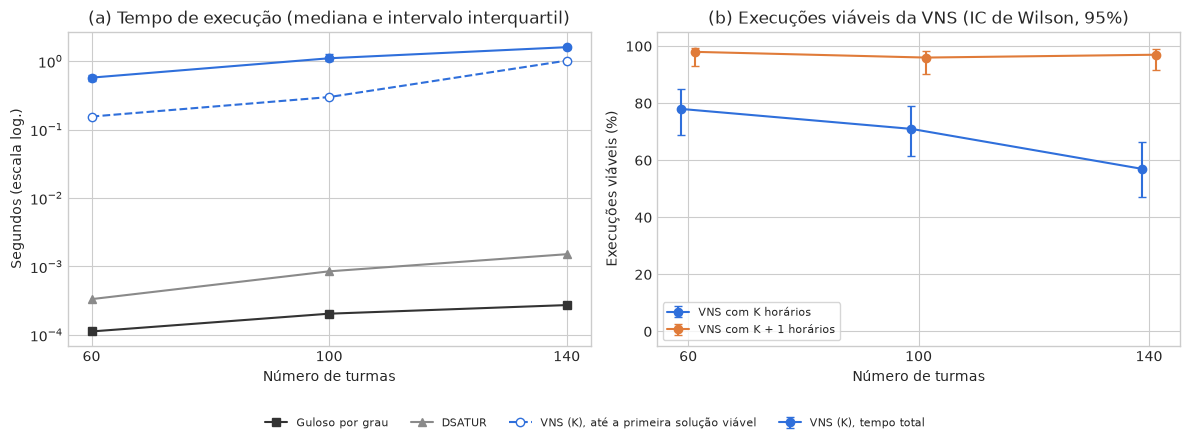

In [ ]:
desenhar_figura(resumo, orcamentos=('K', 'K+1'), arquivo='figura_benchmark.png')

## 8. Família densa: instâncias em que o guloso não é ótimo (item 1 do parecer)

Mesmo gerador, com menos grupos (`0,25·n`) e de 1 a 5 grupos por turma. As candidatas são geradas em sequência, com sementes `5000 + n + 1000·j`, e só entram as que têm **guloso > ω(G)**, até 5 por tamanho. Todas as candidatas examinadas ficam em `candidatas_densa.csv`, para que a seleção possa ser relatada.

Em cada instância selecionada, a VNS roda 10 vezes com K horários (o número do guloso, agora com folga em relação a ω) e 10 vezes com **K − 1**, versão de decisão em que só uma solução sem conflitos superaria o guloso (Galinier; Hertz, 2006). O DSATUR serve de referência: quando atinge ω, prova que K − 1 é viável.

Tempo estimado: cerca de 30 a 40 minutos (os grafos são mais densos e cada busca local é mais cara).

In [ ]:
densa, candidatas = {}, []
for n in TAMANHOS:
    selecionadas = 0
    for j in range(DENSA_MAX_CANDIDATAS):
        parametros = parametros_densa(n, j)
        turmas, grafo = gerar_instancia(**parametros)
        omega = tamanho_maior_clique(grafo)
        k_guloso = horarios_usados(coloracao_gulosa(grafo))
        selecionada = k_guloso > omega
        candidatas.append({'turmas': n, 'candidata': j, 'semente': parametros['seed'], 'omega': omega,
                           'k_guloso': k_guloso, 'k_dsatur': horarios_usados(coloracao_dsatur(grafo)),
                           'selecionada': selecionada})
        if selecionada:
            densa[(n, selecionadas)] = {'turmas': turmas, 'grafo': grafo, 'semente': parametros['seed']}
            selecionadas += 1
            if selecionadas == DENSA_INSTANCIAS_POR_TAMANHO:
                break
    if selecionadas < DENSA_INSTANCIAS_POR_TAMANHO:
        print(f'Atenção: só {selecionadas} instâncias densas com {n} turmas em {DENSA_MAX_CANDIDATAS} candidatas')

candidatas = pd.DataFrame(candidatas)
candidatas.to_csv(f'{PASTA}/candidatas_densa.csv', index=False)

caracteristicas_densa = pd.DataFrame([
    {**caracterizar(d['turmas'], d['grafo'], 'Família densa'), 'indice': i, 'semente': d['semente']}
    for (n, i), d in densa.items()])
caracteristicas_densa.to_csv(f'{PASTA}/instancias_densa.csv', index=False)

# Quantas candidatas foi preciso examinar e com que frequência o guloso ficou acima de ω
selecionadas_df = candidatas[candidatas['selecionada']]
display(pd.DataFrame({
    'examinadas': candidatas.groupby('turmas').size(),
    'guloso_acima_de_omega': selecionadas_df.groupby('turmas').size(),
    'dsatur_igual_omega_nessas': (selecionadas_df['k_dsatur'] == selecionadas_df['omega']).groupby(selecionadas_df['turmas']).sum()}))
tabela2(caracteristicas_densa)

,examinadas,guloso_acima_de_omega,dsatur_igual_omega_nessas
turmas,,,
60,22,5,3
100,18,5,4
140,16,5,5


,instancia,turmas,instancias,arestas,grau_medio,grau_maximo,densidade,maior_grupo,omega
0,Família densa,60,5,942 (885–1012),31.4 (29.5–33.7),49 (45–52),0.532 (0.500–0.572),17 (16–19),17 (16–19)
1,Família densa,100,5,1647 (1608–1951),32.9 (32.2–39.0),58 (54–62),0.333 (0.325–0.394),18 (17–20),18 (17–20)
2,Família densa,140,5,2529 (2400–2704),36.1 (34.3–38.6),64 (62–67),0.260 (0.247–0.278),18 (17–20),18 (17–20)


In [ ]:
construtivos_densa, rodadas_densa = avaliar_familia(densa, deslocamentos=(0, -1), rodadas=RODADAS_VNS_DENSA,
                                                    rotulo='Família densa')
construtivos_densa.to_csv(f'{PASTA}/construtivos_densa.csv', index=False)
rodadas_densa.to_csv(f'{PASTA}/rodadas_vns_densa.csv', index=False)
resumo_densa = resumir_familia(construtivos_densa, rodadas_densa)
resumo_densa.to_csv(f'{PASTA}/resumo_densa.csv', index=False)
display(viabilidade_por_instancia(rodadas_densa))
resumo_densa.T

Família densa: 60 turmas, instância 0 concluída (21:58:06)
Família densa: 60 turmas, instância 1 concluída (21:58:53)
Família densa: 60 turmas, instância 2 concluída (21:59:42)
Família densa: 60 turmas, instância 3 concluída (22:00:39)
Família densa: 60 turmas, instância 4 concluída (22:01:27)
Família densa: 100 turmas, instância 0 concluída (22:02:59)
Família densa: 100 turmas, instância 1 concluída (22:04:47)
Família densa: 100 turmas, instância 2 concluída (22:06:32)
Família densa: 100 turmas, instância 3 concluída (22:08:08)
Família densa: 100 turmas, instância 4 concluída (22:10:14)
Família densa: 140 turmas, instância 0 concluída (22:13:16)
Família densa: 140 turmas, instância 1 concluída (22:15:58)
Família densa: 140 turmas, instância 2 concluída (22:18:38)
Família densa: 140 turmas, instância 3 concluída (22:21:05)
Família densa: 140 turmas, instância 4 concluída (22:24:02)


orcamento         K  K-1
turmas instancia        
60     0          0    0
       1          2    0
       2          2    0
       3          4    2
       4          8    2
100    0          0    0
       1          0    0
       2          2    0
       3          1    0
       4          0    0
140    0          0    0
       1          0    0
       2          0    0
       3          0    0
       4          0    0

,0,1,2,3,4,5
turmas,60,60,100,100,140,140
orcamento,K,K-1,K,K-1,K,K-1
instancias,5,5,5,5,5,5
execucoes,50,50,50,50,50,50
omega_min,16,16,17,17,17,17
omega_max,19,19,20,20,20,20
guloso_igual_omega,0,0,0,0,0,0
dsatur_igual_omega,3,3,4,4,5,5
dsatur_menos_que_guloso,4,4,5,5,5,5
guloso_tempo_mediana_s,0.000282,0.000282,0.000546,0.000546,0.000762,0.000762


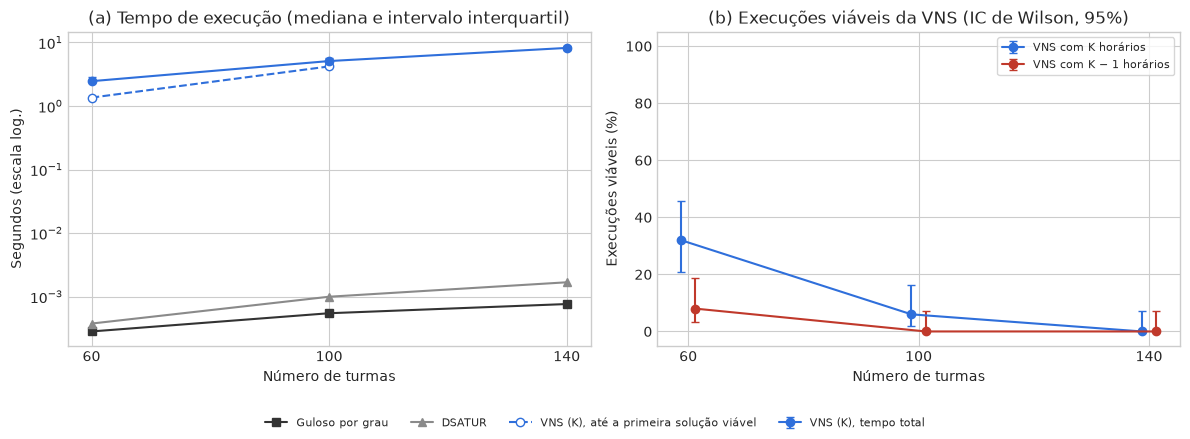

In [ ]:
desenhar_figura(resumo_densa, orcamentos=('K', 'K-1'), arquivo='figura_densa.png')

## 9. Ambiente de execução (seção 4.4)

Registra também o commit do repositório no momento da execução. Faça o commit do notebook antes de rodar para que o hash identifique o código que gerou os resultados.

In [ ]:
def comando(cmd):
    try:
        return subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=10).stdout.strip()
    except Exception:
        return ''

ambiente = {
    'inicio_execucao': INICIO_EXECUCAO,
    'fim_execucao': datetime.now().isoformat(timespec='seconds'),
    'commit': comando('git rev-parse HEAD'),
    'sistema': platform.platform(),
    'python': platform.python_version(),
    'numpy': np.__version__, 'pandas': pd.__version__, 'matplotlib': matplotlib.__version__,
    'processador': comando("lscpu | sed -n 's/^Model name: *//p'") or platform.processor(),
    'cpus_logicas': os.cpu_count(),
    'memoria': comando("free -h | awk '/^Mem:/{print $2}'"),
    'distribuicao': comando("sed -n 's/^PRETTY_NAME=//p' /etc/os-release").strip('"'),
}
with open(f'{PASTA}/ambiente.json', 'w', encoding='utf-8') as f:
    json.dump(ambiente, f, ensure_ascii=False, indent=2)
ambiente

{'inicio_execucao': '2026-10-08T21:45:28',
 'fim_execucao': '2026-10-08T22:24:03',
 'commit': '966d9288ec312b66b962eb602b3a53a61241de9f',
 'sistema': 'Linux-5.15.167.4-microsoft-standard-WSL2-x86_64-with-glibc2.39',
 'python': '3.12.13',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'matplotlib': '3.11.2',
 'processador': 'AMD Ryzen 5 5600G with Radeon Graphics',
 'cpus_logicas': 12,
 'memoria': '7.7Gi',
 'distribuicao': 'Ubuntu 24.04.5 LTS'}

## Observações

- ω(G) é calculado exatamente (Bron–Kerbosch). Quando os horários de um método coincidem com ω(G), ele é ótimo em número de horários naquela instância.
- Na família densa, a seleção por "guloso > ω(G)" é feita antes de rodar a VNS e é relatada em `candidatas_densa.csv`.
- A busca local avalia todas as turmas. Restringi-la às turmas em conflito daria as mesmas escolhas de movimento (uma turma sem conflito nunca reduz conflitos ao mudar de cor) com menos custo, mas mudaria a sequência do gerador aleatório; por isso não foi aplicada.
- Possíveis extensões: partir a VNS da solução gulosa, aceitar candidatos de mesmo custo, outras vizinhanças (troca entre duas turmas, cadeias de Kempe), movimentos que esvaziem uma cor e restrições de salas, capacidade e preferências.